# Actor Trends


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

file_path = "/Users/RaulPerez/Documents/Projects/cumulative_report/data/raw/country_year_final_panel_full_new.csv"
df = pd.read_csv(file_path)

rule_prefixes = (
    "C_", "I_", "P_",
    "IM_", "GOV_", "PRESS_",
    "APPEAL_", "EXEMPTION_", "LAWSUIT", "REG_"
)

value_cols = [c for c in df.columns if str(c).startswith(rule_prefixes)]

id_cols = [c for c in df.columns if c in ["COUNTRY", "year", "iso3"] or str(c).startswith("Unnamed")]

X_presence = (df[value_cols].fillna(0) != 0).astype(int)

# Use the _new panel's authoritative weighted measures under the old
# analysis column names so the existing EDA code runs unchanged.
weighted_aliases = {
    "de_jure": "dj_expression",
    "weighted_de_jure": "wdj_expression",
    "weighted_de_jure_C": "wdj_citizen",
    "weighted_de_jure_I": "wdj_intermediaries",
    "weighted_de_jure_P": "wdj_press",
    "weighted_de_jure_GOV.PROT": "wdj_govprot",
    "weighted_de_jure_RESTRICTION": "wdj_restriction",
    "weighted_de_jure_OBLIGATION": "wdj_obligation",
}

for target, source in weighted_aliases.items():
    if target not in df.columns and source in df.columns:
        df[target] = df[source]

if "legal_rule_count_total" not in df.columns:
    df["legal_rule_count_total"] = X_presence.sum(axis=1)

if "legal_rule_count_RESTRICTION" not in df.columns:
    restriction_cols = [c for c in value_cols if "_EXPRESS_" in c]
    df["legal_rule_count_RESTRICTION"] = X_presence[restriction_cols].sum(axis=1)

if "legal_rule_count_OBLIGATION" not in df.columns:
    obligation_cols = [
        c for c in value_cols
        if c.startswith(("IM_", "GOV_", "PRESS_", "APPEAL_", "EXEMPTION_", "LAWSUIT", "REG_"))
    ]
    df["legal_rule_count_OBLIGATION"] = X_presence[obligation_cols].sum(axis=1)


print("Dataset shape:", df.shape)
print("Number of rule columns:", len(value_cols))
print("First 10 rule columns:", value_cols[:10])

Dataset shape: (8580, 753)
Number of rule columns: 730
First 10 rule columns: ['C_DISINFO_GEN', 'I_DISINFO_GEN', 'P_DISINFO_GEN', 'C_DISINFO_GEN_DIGI', 'I_DISINFO_GEN_DIGI', 'P_DISINFO_GEN_DIGI', 'C_DISINFO_GEN_CRISIS', 'I_DISINFO_GEN_CRISIS', 'P_DISINFO_GEN_CRISIS', 'C_MALINFO_GEN']


## Actor Column Groups


In [2]:
press_cols = [c for c in value_cols if c.startswith("P_")]
internet_cols = [c for c in value_cols if c.startswith("I_")]
press_gov_cols = [c for c in value_cols if c.startswith("PRESS_")]
im_cols = [c for c in value_cols if c.startswith("IM_")]

print("Press columns:", len(press_cols))
print("Internet/platform columns:", len(internet_cols))
print("Press governance columns:", len(press_gov_cols))
print("Intermediary governance columns:", len(im_cols))


Press columns: 225
Internet/platform columns: 225
Press governance columns: 10
Intermediary governance columns: 22


## Press and Internet Rule Presence


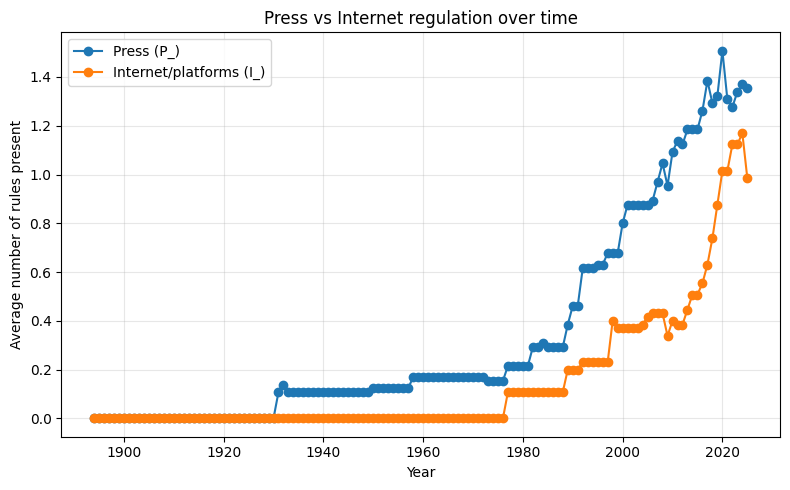

In [3]:
yearly_press_i = pd.DataFrame({
    "year": df["year"],
    "press_presence": X_presence[press_cols].sum(axis=1),
    "internet_presence": X_presence[internet_cols].sum(axis=1)
})

yearly_press_i_avg = (
    yearly_press_i.groupby("year")[["press_presence", "internet_presence"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(yearly_press_i_avg["year"], yearly_press_i_avg["press_presence"], marker="o", label="Press (P_)")
plt.plot(yearly_press_i_avg["year"], yearly_press_i_avg["internet_presence"], marker="o", label="Internet/platforms (I_)")
plt.xlabel("Year")
plt.ylabel("Average number of rules present")
plt.title("Press vs Internet regulation over time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

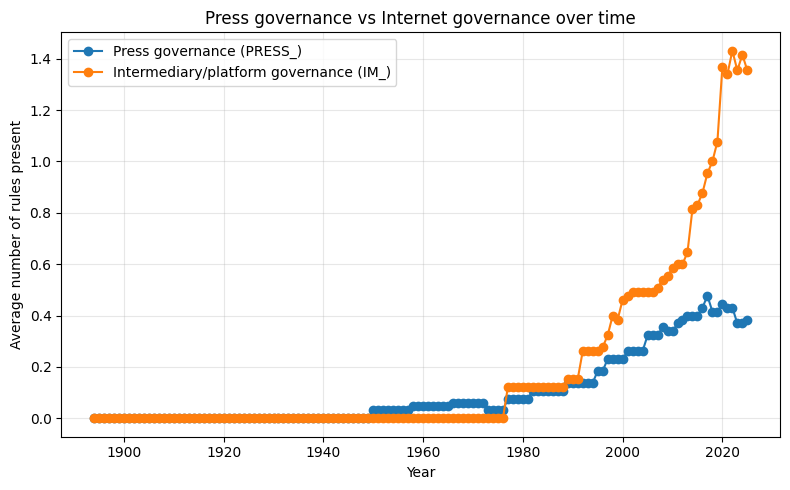

In [4]:
yearly_gov = pd.DataFrame({
    "year": df["year"],
    "press_governance_presence": X_presence[press_gov_cols].sum(axis=1),
    "intermediary_presence": X_presence[im_cols].sum(axis=1)
})

yearly_gov_avg = (
    yearly_gov.groupby("year")[["press_governance_presence", "intermediary_presence"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(yearly_gov_avg["year"], yearly_gov_avg["press_governance_presence"], marker="o", label="Press governance (PRESS_)")
plt.plot(yearly_gov_avg["year"], yearly_gov_avg["intermediary_presence"], marker="o", label="Intermediary/platform governance (IM_)")
plt.xlabel("Year")
plt.ylabel("Average number of rules present")
plt.title("Press governance vs Internet governance over time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
def plot_rule_counts_by_year(df, X_presence, family_cols, title):
    yearly_rule_counts = (
        pd.concat([df[["year"]], X_presence[family_cols]], axis=1)
        .groupby("year")[family_cols]
        .sum()
        .reset_index()
    )

    family_cols = [c for c in family_cols if yearly_rule_counts[c].max() >= 3]

    plt.figure(figsize=(12, 7))

    for col in family_cols:
        plt.plot(
            yearly_rule_counts["year"],
            yearly_rule_counts[col],
            linewidth=1.8,
            alpha=0.9,
            label=col
        )

    plt.xlabel("Year")
    plt.ylabel("Number of countries with rule present")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

    return yearly_rule_counts

In [10]:
social_press_cols = press_cols + internet_cols + press_gov_cols + im_cols
selected_years = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]

In [11]:
def top_rules_for_year(df, X_presence, cols, year, top_n=5):
    year_mask = df["year"] == year
    counts = X_presence.loc[year_mask, cols].sum().sort_values(ascending=False).head(top_n)
    return counts.reset_index().rename(columns={"index": "rule", 0: "count"})

In [12]:
for year in selected_years:
    top_df = top_rules_for_year(df, X_presence, social_press_cols, year, top_n=5)
    print(year)
    display(top_df)

1990


,rule,count
0,P_EXPRESS_MORAL,3
1,P_EXPRESS_GOVCRITIC,3
2,PRESS_LICENSE,3
3,PRESS_REPORT,2
4,PRESS_OVERSIGHT,2


1995


,rule,count
0,P_EXPRESS_MORAL,4
1,P_EXPRESS_GOVCRITIC,4
2,PRESS_LICENSE,4
3,P_EXPRESS_HATE,3
4,IM_REPORT,3


2000


...

,rule,count
0,IM_REPORT,11
1,IM_OVERSIGHT,10
2,IM_LICENSE,10
3,PRESS_REPORT,8
4,PRESS_LICENSE,8


2020


,rule,count
0,IM_OVERSIGHT,17
1,IM_REPORT,15
2,IM_PREVENTION,14
3,IM_LICENSE,12
4,IM_DEPLATFORM,11


2025


,rule,count
0,IM_OVERSIGHT,18
1,IM_REPORT,14
2,IM_PREVENTION,14
3,IM_DEPLATFORM,11
4,IM_LICENSE,9


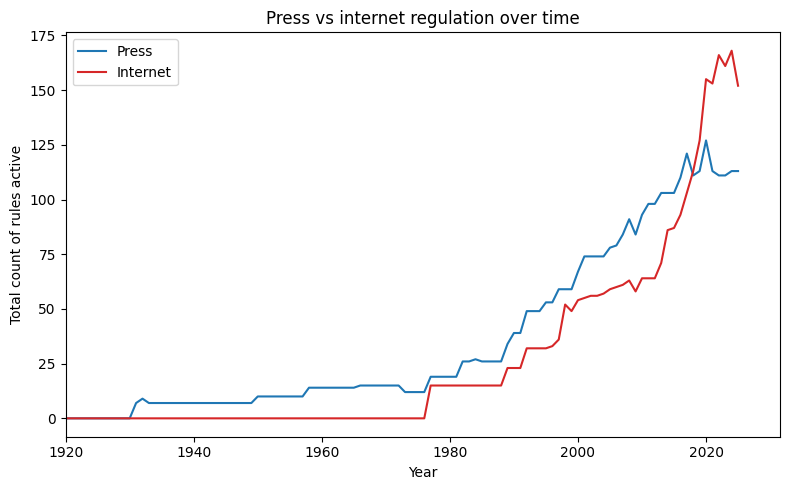

In [14]:
press_combined_cols = press_cols + press_gov_cols
internet_combined_cols = internet_cols + im_cols

yearly_combined_counts = pd.DataFrame({
    "year": df["year"],
    "press_total": X_presence[press_combined_cols].sum(axis=1),
    "internet_total": X_presence[internet_combined_cols].sum(axis=1)
})

yearly_combined_counts = (
    yearly_combined_counts.groupby("year")[["press_total", "internet_total"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(
    yearly_combined_counts["year"],
    yearly_combined_counts["press_total"],
    label="Press",
    color="#1f77b4"
)
plt.plot(
    yearly_combined_counts["year"],
    yearly_combined_counts["internet_total"],
    label="Internet",
    color="#d62728"
)
plt.xlim(left=1920)
plt.xlabel("Year")
plt.ylabel("Total count of rules active")
plt.title("Press vs internet regulation over time")
plt.legend()
plt.tight_layout()
plt.show()

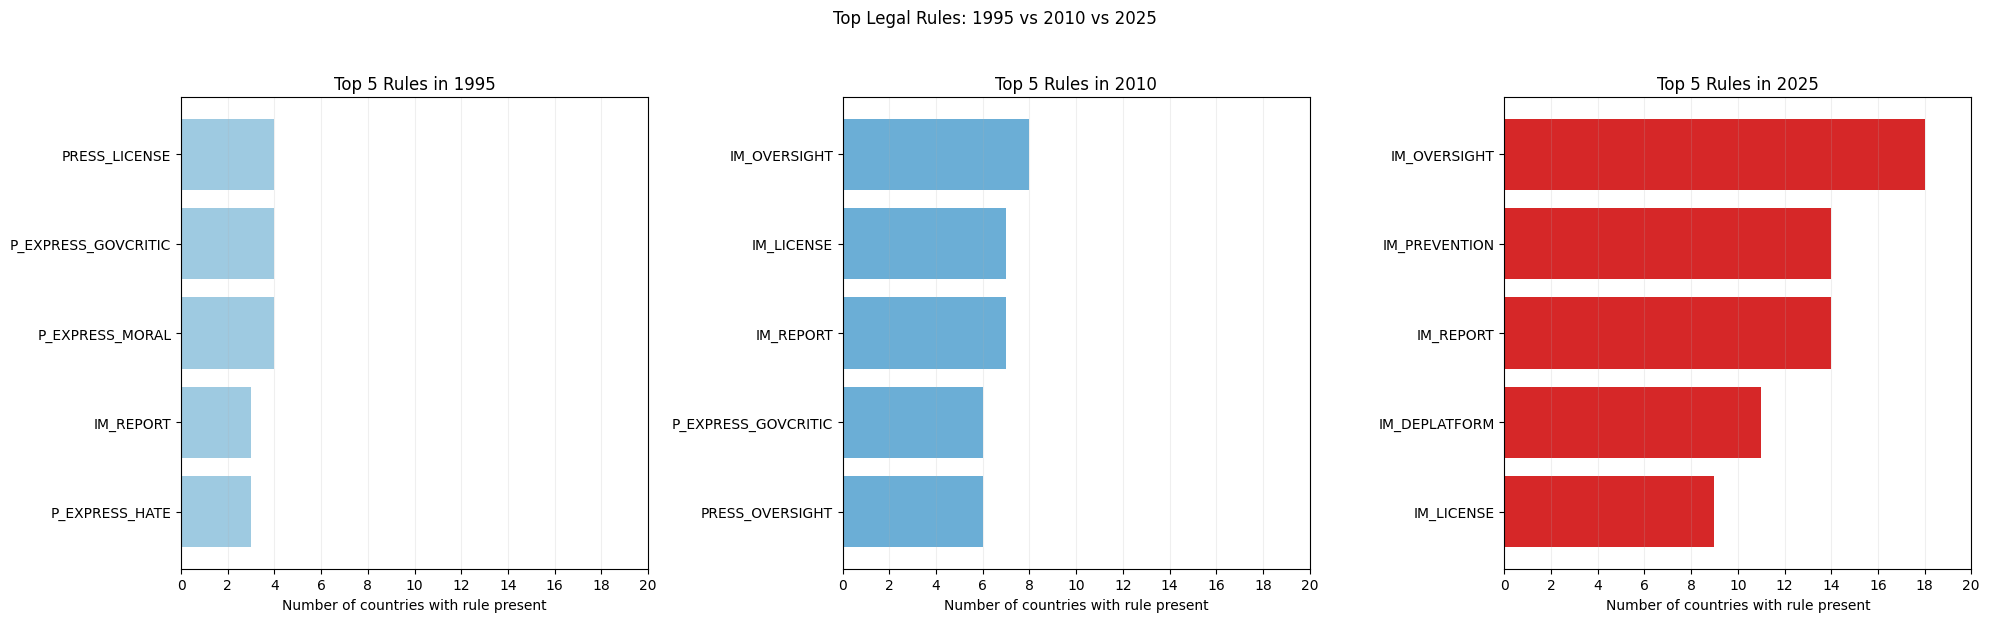

,rule,count,year
0,P_EXPRESS_HATE,3,1995
1,IM_REPORT,3,1995
2,P_EXPRESS_MORAL,4,1995
3,P_EXPRESS_GOVCRITIC,4,1995
4,PRESS_LICENSE,4,1995
5,PRESS_OVERSIGHT,6,2010
6,P_EXPRESS_GOVCRITIC,6,2010
7,IM_REPORT,7,2010
8,IM_LICENSE,7,2010
9,IM_OVERSIGHT,8,2010


In [15]:
from matplotlib.ticker import MaxNLocator

compare_years = [1995, 2010, 2025]
top_n = 5

year_dfs = {
    year: top_rules_for_year(df, X_presence, social_press_cols, year, top_n=top_n)
    .sort_values("count", ascending=True)
    for year in compare_years
}

year_colors = {
    1995: "#9ecae1",
    2010: "#6baed6",
    2025: "#d62728"
}

max_count = max(year_dfs[year]["count"].max() for year in compare_years)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)

for ax, year in zip(axes, compare_years):
    plot_df = year_dfs[year]
    ax.barh(plot_df["rule"], plot_df["count"], color=year_colors[year])
    ax.set_title(f"Top {top_n} Rules in {year}")
    ax.set_xlabel("Number of countries with rule present")
    ax.set_xlim(0, max_count + 2)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, axis="x", alpha=0.2)

plt.suptitle("Top Legal Rules: 1995 vs 2010 vs 2025", y=1.03)
plt.tight_layout()
plt.show()

pd.concat(
    [year_dfs[year].assign(year=year) for year in compare_years],
    ignore_index=True
)

## Citizens, Press, and Internet Weighted Scores


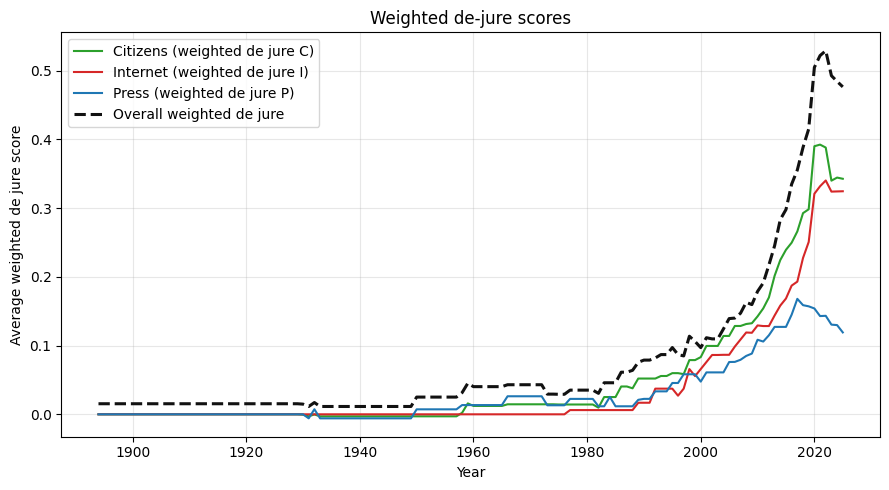

,year,weighted_de_jure_C,weighted_de_jure_I,weighted_de_jure_P,weighted_de_jure
0,1894,0.000000,0.000000,0.000000,0.015385
1,1895,0.000000,0.000000,0.000000,0.015385
2,1896,0.000000,0.000000,0.000000,0.015385
3,1897,0.000000,0.000000,0.000000,0.015385
4,1898,0.000000,0.000000,0.000000,0.015385
...,...,...,...,...,...
127,2021,0.392489,0.331868,0.142984,0.522036
128,2022,0.388191,0.340284,0.143340,0.529132
129,2023,0.340044,0.324092,0.130513,0.492783
130,2024,0.344505,0.324272,0.129829,0.484416


In [17]:
weighted_de_jure_trends = (
    df.groupby("year")[[
        "weighted_de_jure_C",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "weighted_de_jure"
    ]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(
    weighted_de_jure_trends["year"],
    weighted_de_jure_trends["weighted_de_jure_C"],
    label="Citizens (weighted de jure C)",
    color="#2ca02c"
)
plt.plot(
    weighted_de_jure_trends["year"],
    weighted_de_jure_trends["weighted_de_jure_I"],
    label="Internet (weighted de jure I)",
    color="#d62728"
)
plt.plot(
    weighted_de_jure_trends["year"],
    weighted_de_jure_trends["weighted_de_jure_P"],
    label="Press (weighted de jure P)",
    color="#1f77b4"
)
plt.plot(
    weighted_de_jure_trends["year"],
    weighted_de_jure_trends["weighted_de_jure"],
    label="Overall weighted de jure",
    color="#111111",
    linewidth=2.2,
    linestyle="--"
)
plt.xlabel("Year")
plt.ylabel("Average weighted de jure score")
plt.title("Weighted de-jure scores")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

weighted_de_jure_trends

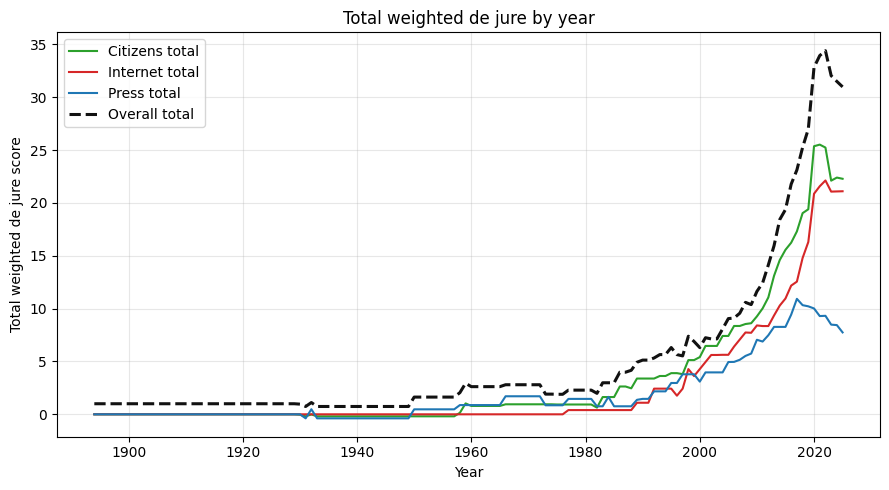

,year,weighted_de_jure_C,weighted_de_jure_I,weighted_de_jure_P,weighted_de_jure
0,1894,0.000000,0.000000,0.000000,1.000000
1,1895,0.000000,0.000000,0.000000,1.000000
2,1896,0.000000,0.000000,0.000000,1.000000
3,1897,0.000000,0.000000,0.000000,1.000000
4,1898,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...
127,2021,25.511787,21.571443,9.293946,33.932310
128,2022,25.232421,22.118451,9.317094,34.393557
129,2023,22.102845,21.065982,8.483333,32.030891
130,2024,22.392828,21.077707,8.438889,31.487044


In [18]:
weighted_de_jure_totals = (
    df.groupby("year")[[
        "weighted_de_jure_C",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "weighted_de_jure"
    ]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(
    weighted_de_jure_totals["year"],
    weighted_de_jure_totals["weighted_de_jure_C"],
    label="Citizens total",
    color="#2ca02c"
)
plt.plot(
    weighted_de_jure_totals["year"],
    weighted_de_jure_totals["weighted_de_jure_I"],
    label="Internet total",
    color="#d62728"
)
plt.plot(
    weighted_de_jure_totals["year"],
    weighted_de_jure_totals["weighted_de_jure_P"],
    label="Press total",
    color="#1f77b4"
)
plt.plot(
    weighted_de_jure_totals["year"],
    weighted_de_jure_totals["weighted_de_jure"],
    label="Overall total",
    color="#111111",
    linewidth=2.2,
    linestyle="--"
)
plt.xlabel("Year")
plt.ylabel("Total weighted de jure score")
plt.title("Total weighted de jure by year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

weighted_de_jure_totals

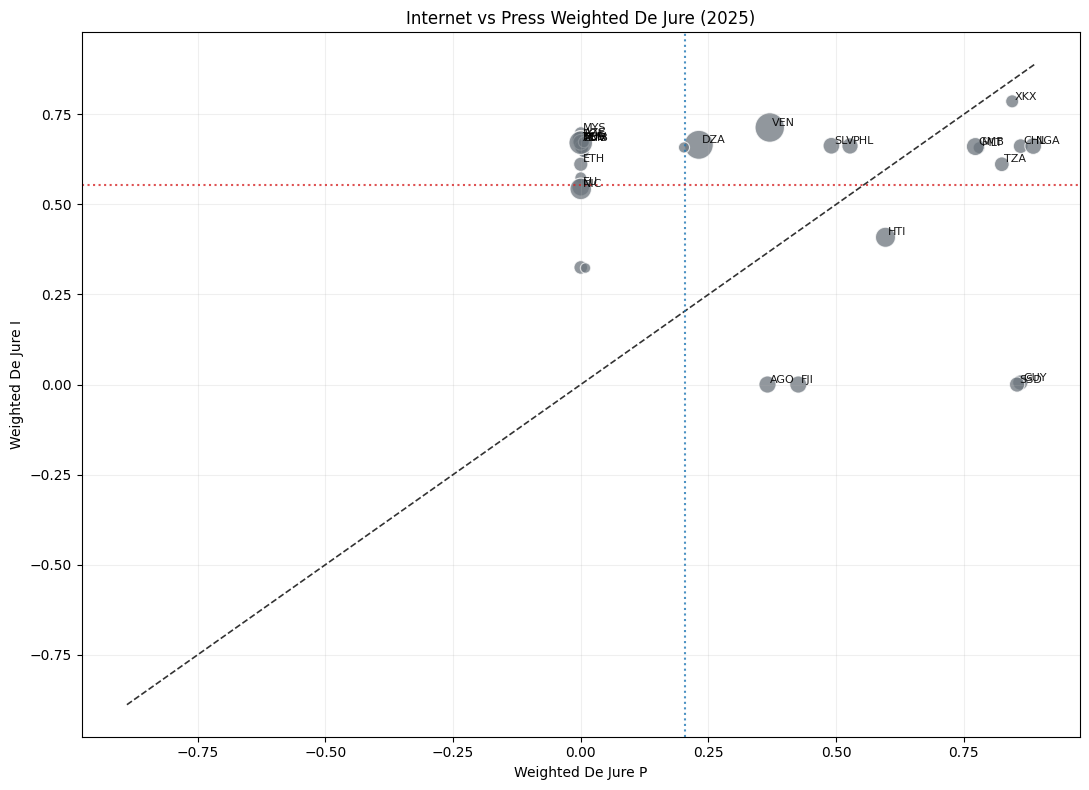

,COUNTRY,iso3,weighted_de_jure_I,weighted_de_jure_P,legal_rule_count_total,bubble_size,weighted_de_jure_P_jitter,weighted_de_jure_I_jitter,gap
8183,Venezuela,VEN,0.709402,0.374074,56,448,0.370166,0.713539,0.335328
395,Algeria,DZA,0.666667,0.222222,54,432,0.231237,0.665470,0.444444
8447,Zambia,ZMB,0.666667,-0.380952,36,288,0.000000,0.671247,1.047619
5147,Nicaragua,NIC,0.545455,0.000000,30,240,0.000000,0.543228,0.545455
3299,Haiti,HTI,0.400000,0.603175,26,208,0.596811,0.408790,0.203175
7523,The Gambia,GMB,0.666667,0.763889,21,168,0.772867,0.660641,0.097222
3563,Hungary,HUN,0.666667,0.000000,21,168,0.000000,0.674563,0.666667
2639,European Union,EU,0.547009,0.000000,20,160,0.000000,0.547943,0.547009
527,Angola,AGO,0.000000,0.361111,19,152,0.365751,0.000000,0.361111
5939,Poland,POL,0.680556,-0.888889,19,152,0.000000,0.681409,1.569444


In [19]:
plot_year = 2025

scatter_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

scatter_df = scatter_df[
    (scatter_df["weighted_de_jure_P"] > 0) |
    (scatter_df["weighted_de_jure_I"] > 0)
].copy()

scatter_df["bubble_size"] = scatter_df["legal_rule_count_total"] * 8

np.random.seed(42)
scatter_df["weighted_de_jure_P_jitter"] = (
    scatter_df["weighted_de_jure_P"] + np.random.uniform(-0.01, 0.01, len(scatter_df))
)
scatter_df["weighted_de_jure_I_jitter"] = (
    scatter_df["weighted_de_jure_I"] + np.random.uniform(-0.01, 0.01, len(scatter_df))
)
scatter_df["weighted_de_jure_P_jitter"] = scatter_df["weighted_de_jure_P_jitter"].clip(lower=0)
scatter_df["weighted_de_jure_I_jitter"] = scatter_df["weighted_de_jure_I_jitter"].clip(lower=0)

scatter_df["gap"] = (
    scatter_df["weighted_de_jure_I"] - scatter_df["weighted_de_jure_P"]
).abs()

label_df = pd.concat([
    scatter_df.nlargest(12, "legal_rule_count_total"),
    scatter_df.nlargest(10, "gap"),
    scatter_df.nlargest(10, "weighted_de_jure_I"),
    scatter_df.nlargest(10, "weighted_de_jure_P")
]).drop_duplicates(subset="iso3")

x_min = scatter_df["weighted_de_jure_P"].min()
x_max = scatter_df["weighted_de_jure_P"].max()
y_min = scatter_df["weighted_de_jure_I"].min()
y_max = scatter_df["weighted_de_jure_I"].max()
line_min = min(x_min, y_min)
line_max = max(x_max, y_max)

p_mean = scatter_df["weighted_de_jure_P"].mean()
i_mean = scatter_df["weighted_de_jure_I"].mean()

plt.figure(figsize=(11, 8))
plt.scatter(
    scatter_df["weighted_de_jure_P_jitter"],
    scatter_df["weighted_de_jure_I_jitter"],
    s=scatter_df["bubble_size"],
    color="#6c757d",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8
)

for _, row in label_df.iterrows():
    plt.text(
        row["weighted_de_jure_P_jitter"] + 0.005,
        row["weighted_de_jure_I_jitter"] + 0.005,
        row["iso3"],
        fontsize=8,
        alpha=0.9
    )

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color="black",
    linewidth=1.2,
    alpha=0.8
)

plt.axvline(p_mean, linestyle=":", color="#1f77b4", alpha=0.8)
plt.axhline(i_mean, linestyle=":", color="#d62728", alpha=0.8)

plt.xlabel("Weighted De Jure P")
plt.ylabel("Weighted De Jure I")
plt.title(f"Internet vs Press Weighted De Jure ({plot_year})")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

scatter_df.sort_values("legal_rule_count_total", ascending=False)

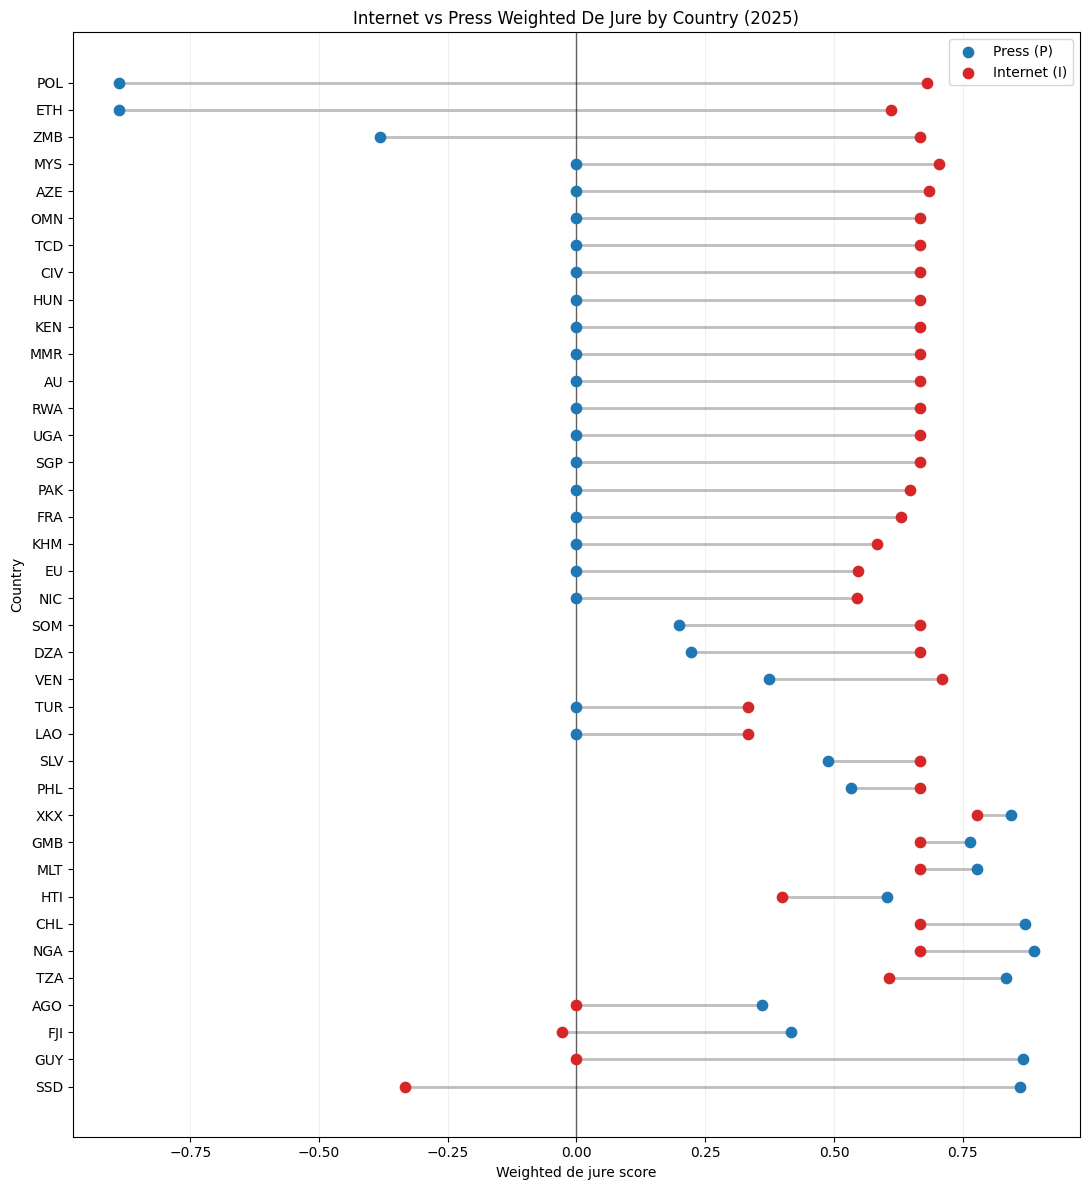

,COUNTRY,iso3,weighted_de_jure_P,weighted_de_jure_I,gap,legal_rule_count_total
0,South Sudan,SSD,0.861111,-0.333333,-1.194444,15
1,Guyana,GUY,0.866667,0.000000,-0.866667,15
2,Fiji,FJI,0.416667,-0.027778,-0.444444,19
3,Angola,AGO,0.361111,0.000000,-0.361111,19
4,Tanzania,TZA,0.833333,0.606061,-0.227273,14
5,Nigeria,NGA,0.888889,0.666667,-0.222222,18
6,Chile,CHL,0.870370,0.666667,-0.203704,14
7,Haiti,HTI,0.603175,0.400000,-0.203175,26
8,Malta,MLT,0.777778,0.666667,-0.111111,9
9,The Gambia,GMB,0.763889,0.666667,-0.097222,21


In [20]:
plot_year = 2025

dumbbell_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

dumbbell_df = dumbbell_df[
    (dumbbell_df["weighted_de_jure_I"] != 0) |
    (dumbbell_df["weighted_de_jure_P"] != 0)
].copy()

dumbbell_df["gap"] = (
    dumbbell_df["weighted_de_jure_I"] - dumbbell_df["weighted_de_jure_P"]
)

dumbbell_df = dumbbell_df.sort_values("gap").reset_index(drop=True)
y_pos = np.arange(len(dumbbell_df))

plt.figure(figsize=(11, 12))

for i, row in dumbbell_df.iterrows():
    plt.plot(
        [row["weighted_de_jure_P"], row["weighted_de_jure_I"]],
        [y_pos[i], y_pos[i]],
        color="#bdbdbd",
        linewidth=2,
        zorder=1
    )

plt.scatter(
    dumbbell_df["weighted_de_jure_P"],
    y_pos,
    color="#1f77b4",
    s=55,
    label="Press (P)",
    zorder=3
)

plt.scatter(
    dumbbell_df["weighted_de_jure_I"],
    y_pos,
    color="#d62728",
    s=55,
    label="Internet (I)",
    zorder=3
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, dumbbell_df["iso3"])
plt.xlabel("Weighted de jure score")
plt.ylabel("Country")
plt.title(f"Internet vs Press Weighted De Jure by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

dumbbell_df[["COUNTRY", "iso3", "weighted_de_jure_P", "weighted_de_jure_I", "gap", "legal_rule_count_total"]]


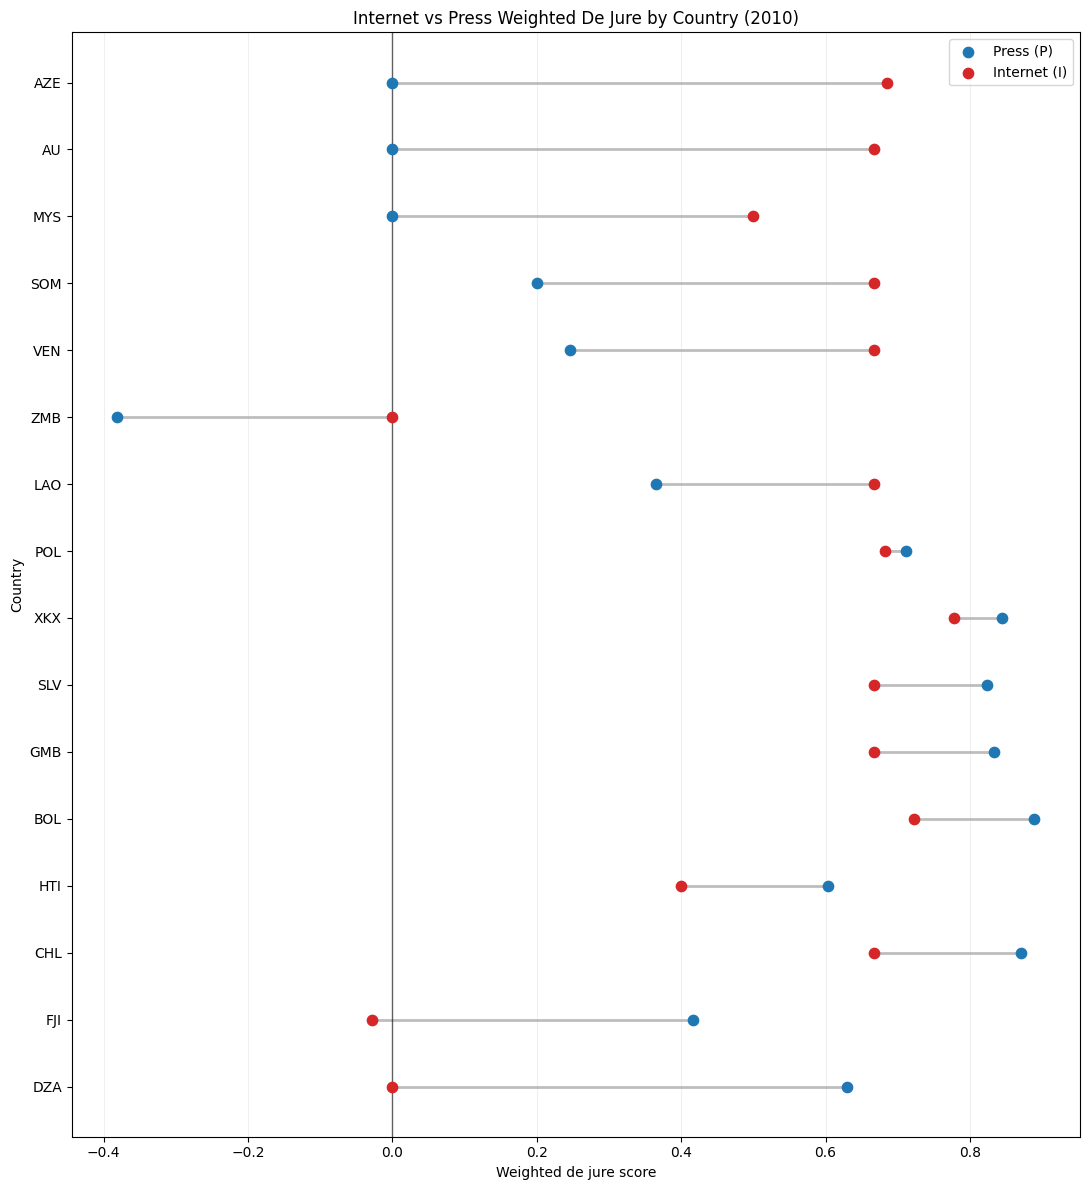

,COUNTRY,iso3,weighted_de_jure_P,weighted_de_jure_I,gap,legal_rule_count_total
0,Algeria,DZA,0.629630,0.000000,-0.629630,48
1,Fiji,FJI,0.416667,-0.027778,-0.444444,19
2,Chile,CHL,0.870370,0.666667,-0.203704,14
3,Haiti,HTI,0.603175,0.400000,-0.203175,26
4,Bolivia,BOL,0.888889,0.722222,-0.166667,10
5,The Gambia,GMB,0.833333,0.666667,-0.166667,7
6,El Salvador,SLV,0.824074,0.666667,-0.157407,21
7,Kosovo,XKX,0.844444,0.777778,-0.066667,12
8,Poland,POL,0.711111,0.682540,-0.028571,43
9,Laos,LAO,0.365079,0.666667,0.301587,13


In [21]:
plot_year = 2010

dumbbell_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

dumbbell_df = dumbbell_df[
    (dumbbell_df["weighted_de_jure_I"] != 0) |
    (dumbbell_df["weighted_de_jure_P"] != 0)
].copy()

dumbbell_df["gap"] = (
    dumbbell_df["weighted_de_jure_I"] - dumbbell_df["weighted_de_jure_P"]
)

dumbbell_df = dumbbell_df.sort_values("gap").reset_index(drop=True)
y_pos = np.arange(len(dumbbell_df))

plt.figure(figsize=(11, 12))

for i, row in dumbbell_df.iterrows():
    plt.plot(
        [row["weighted_de_jure_P"], row["weighted_de_jure_I"]],
        [y_pos[i], y_pos[i]],
        color="#bdbdbd",
        linewidth=2,
        zorder=1
    )

plt.scatter(
    dumbbell_df["weighted_de_jure_P"],
    y_pos,
    color="#1f77b4",
    s=55,
    label="Press (P)",
    zorder=3
)

plt.scatter(
    dumbbell_df["weighted_de_jure_I"],
    y_pos,
    color="#d62728",
    s=55,
    label="Internet (I)",
    zorder=3
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, dumbbell_df["iso3"])
plt.xlabel("Weighted de jure score")
plt.ylabel("Country")
plt.title(f"Internet vs Press Weighted De Jure by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

dumbbell_df[["COUNTRY", "iso3", "weighted_de_jure_P", "weighted_de_jure_I", "gap", "legal_rule_count_total"]]


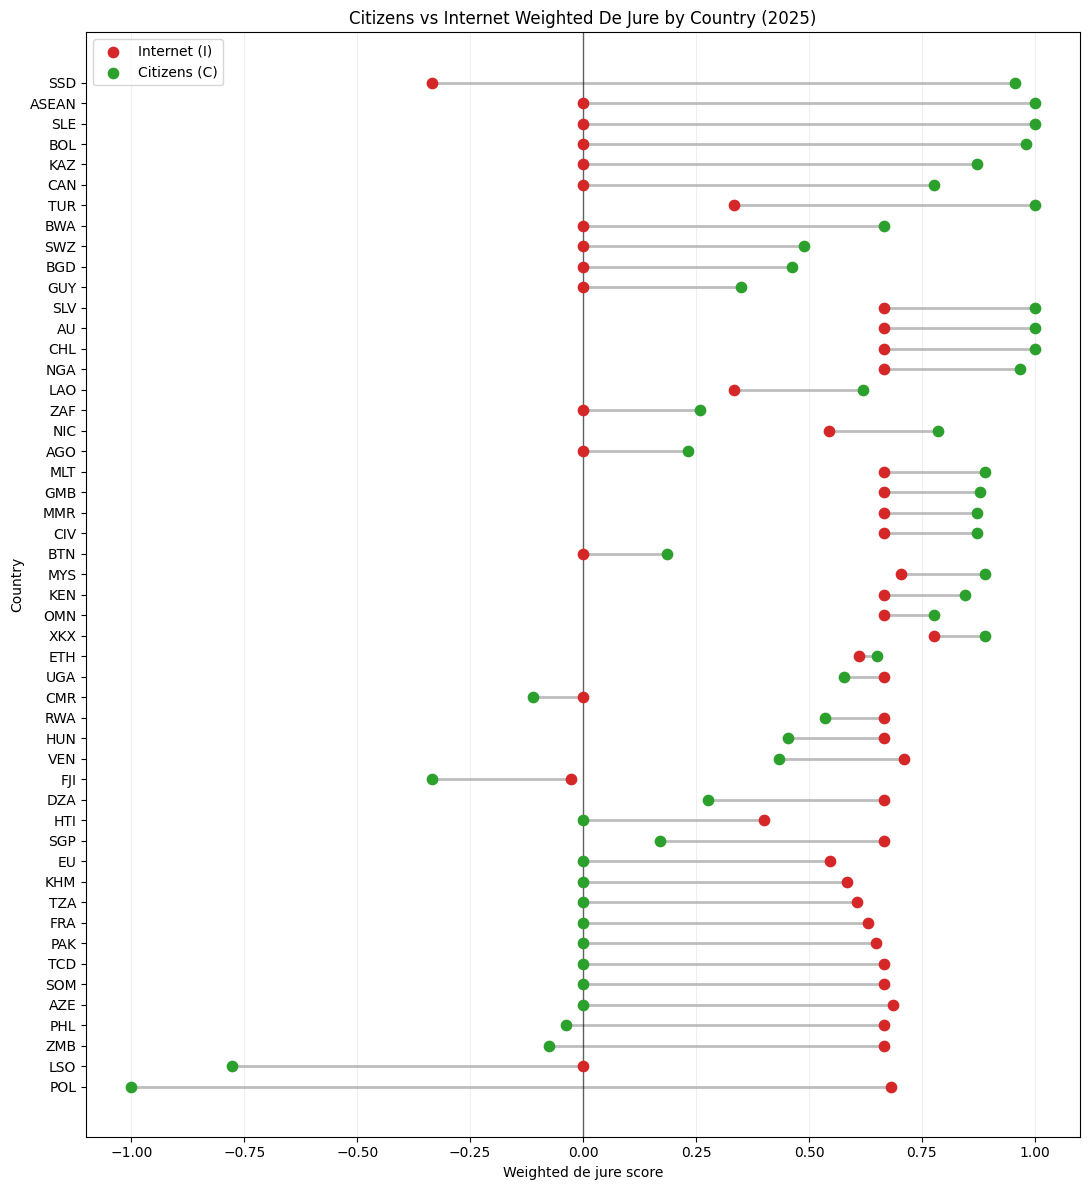

,COUNTRY,iso3,weighted_de_jure_I,weighted_de_jure_C,gap,legal_rule_count_total
0,Poland,POL,0.680556,-1.000000,-1.680556,19
1,Lesotho,LSO,0.000000,-0.777778,-0.777778,1
2,Zambia,ZMB,0.666667,-0.076023,-0.742690,36
3,Philippines,PHL,0.666667,-0.037037,-0.703704,17
4,Azerbaijan,AZE,0.685185,0.000000,-0.685185,9
5,Somalia,SOM,0.666667,0.000000,-0.666667,8
6,Chad,TCD,0.666667,0.000000,-0.666667,5
7,Pakistan,PAK,0.648148,0.000000,-0.648148,8
8,France,FRA,0.629630,0.000000,-0.629630,3
9,Tanzania,TZA,0.606061,0.000000,-0.606061,14


In [22]:
plot_year = 2025

c_vs_i_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_C",
        "weighted_de_jure_I",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

c_vs_i_df = c_vs_i_df[
    (c_vs_i_df["weighted_de_jure_C"] != 0) |
    (c_vs_i_df["weighted_de_jure_I"] != 0)
].copy()

c_vs_i_df["gap"] = (
    c_vs_i_df["weighted_de_jure_C"] - c_vs_i_df["weighted_de_jure_I"]
)

c_vs_i_df = c_vs_i_df.sort_values("gap").reset_index(drop=True)
y_pos = np.arange(len(c_vs_i_df))

plt.figure(figsize=(11, 12))

for i, row in c_vs_i_df.iterrows():
    plt.plot(
        [row["weighted_de_jure_I"], row["weighted_de_jure_C"]],
        [y_pos[i], y_pos[i]],
        color="#bdbdbd",
        linewidth=2,
        zorder=1
    )

plt.scatter(
    c_vs_i_df["weighted_de_jure_I"],
    y_pos,
    color="#d62728",
    s=55,
    label="Internet (I)",
    zorder=3
)

plt.scatter(
    c_vs_i_df["weighted_de_jure_C"],
    y_pos,
    color="#2ca02c",
    s=55,
    label="Citizens (C)",
    zorder=3
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, c_vs_i_df["iso3"])
plt.xlabel("Weighted de jure score")
plt.ylabel("Country")
plt.title(f"Citizens vs Internet Weighted De Jure by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

c_vs_i_df[["COUNTRY", "iso3", "weighted_de_jure_I", "weighted_de_jure_C", "gap", "legal_rule_count_total"]]


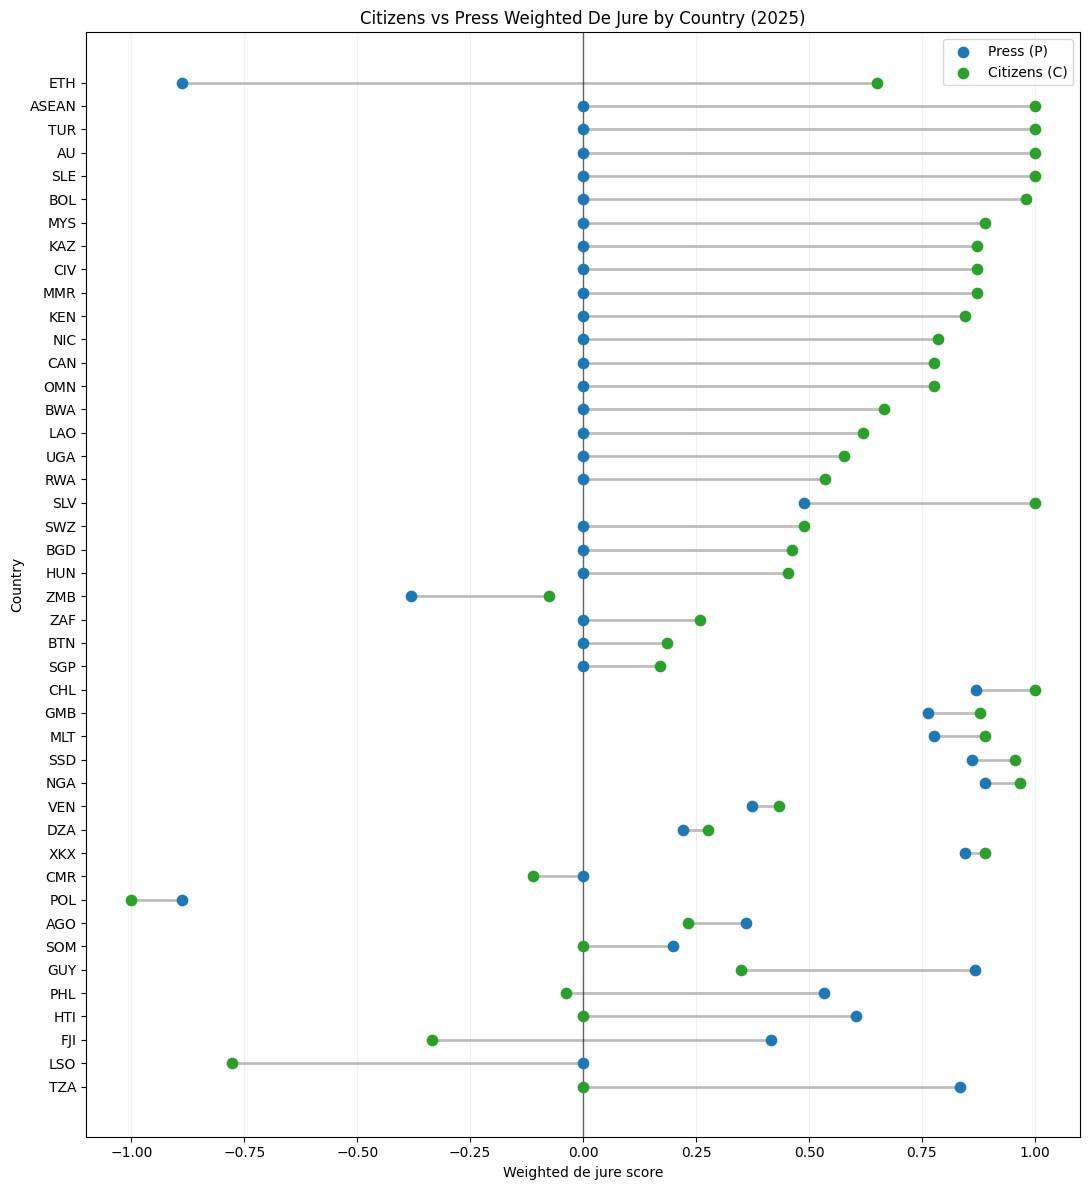

,COUNTRY,iso3,weighted_de_jure_P,weighted_de_jure_C,gap,legal_rule_count_total
0,Tanzania,TZA,0.833333,0.000000,-0.833333,14
1,Lesotho,LSO,0.000000,-0.777778,-0.777778,1
2,Fiji,FJI,0.416667,-0.333333,-0.750000,19
3,Haiti,HTI,0.603175,0.000000,-0.603175,26
4,Philippines,PHL,0.533333,-0.037037,-0.570370,17
5,Guyana,GUY,0.866667,0.349206,-0.517460,15
6,Somalia,SOM,0.200000,0.000000,-0.200000,8
7,Angola,AGO,0.361111,0.232323,-0.128788,19
8,Poland,POL,-0.888889,-1.000000,-0.111111,19
9,Cameroon,CMR,0.000000,-0.111111,-0.111111,9


In [23]:
plot_year = 2025

c_vs_p_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_C",
        "weighted_de_jure_P",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

c_vs_p_df = c_vs_p_df[
    (c_vs_p_df["weighted_de_jure_C"] != 0) |
    (c_vs_p_df["weighted_de_jure_P"] != 0)
].copy()

c_vs_p_df["gap"] = (
    c_vs_p_df["weighted_de_jure_C"] - c_vs_p_df["weighted_de_jure_P"]
)

c_vs_p_df = c_vs_p_df.sort_values("gap").reset_index(drop=True)
y_pos = np.arange(len(c_vs_p_df))

plt.figure(figsize=(11, 12))

for i, row in c_vs_p_df.iterrows():
    plt.plot(
        [row["weighted_de_jure_P"], row["weighted_de_jure_C"]],
        [y_pos[i], y_pos[i]],
        color="#bdbdbd",
        linewidth=2,
        zorder=1
    )

plt.scatter(
    c_vs_p_df["weighted_de_jure_P"],
    y_pos,
    color="#1f77b4",
    s=55,
    label="Press (P)",
    zorder=3
)

plt.scatter(
    c_vs_p_df["weighted_de_jure_C"],
    y_pos,
    color="#2ca02c",
    s=55,
    label="Citizens (C)",
    zorder=3
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, c_vs_p_df["iso3"])
plt.xlabel("Weighted de jure score")
plt.ylabel("Country")
plt.title(f"Citizens vs Press Weighted De Jure by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

c_vs_p_df[["COUNTRY", "iso3", "weighted_de_jure_P", "weighted_de_jure_C", "gap", "legal_rule_count_total"]]


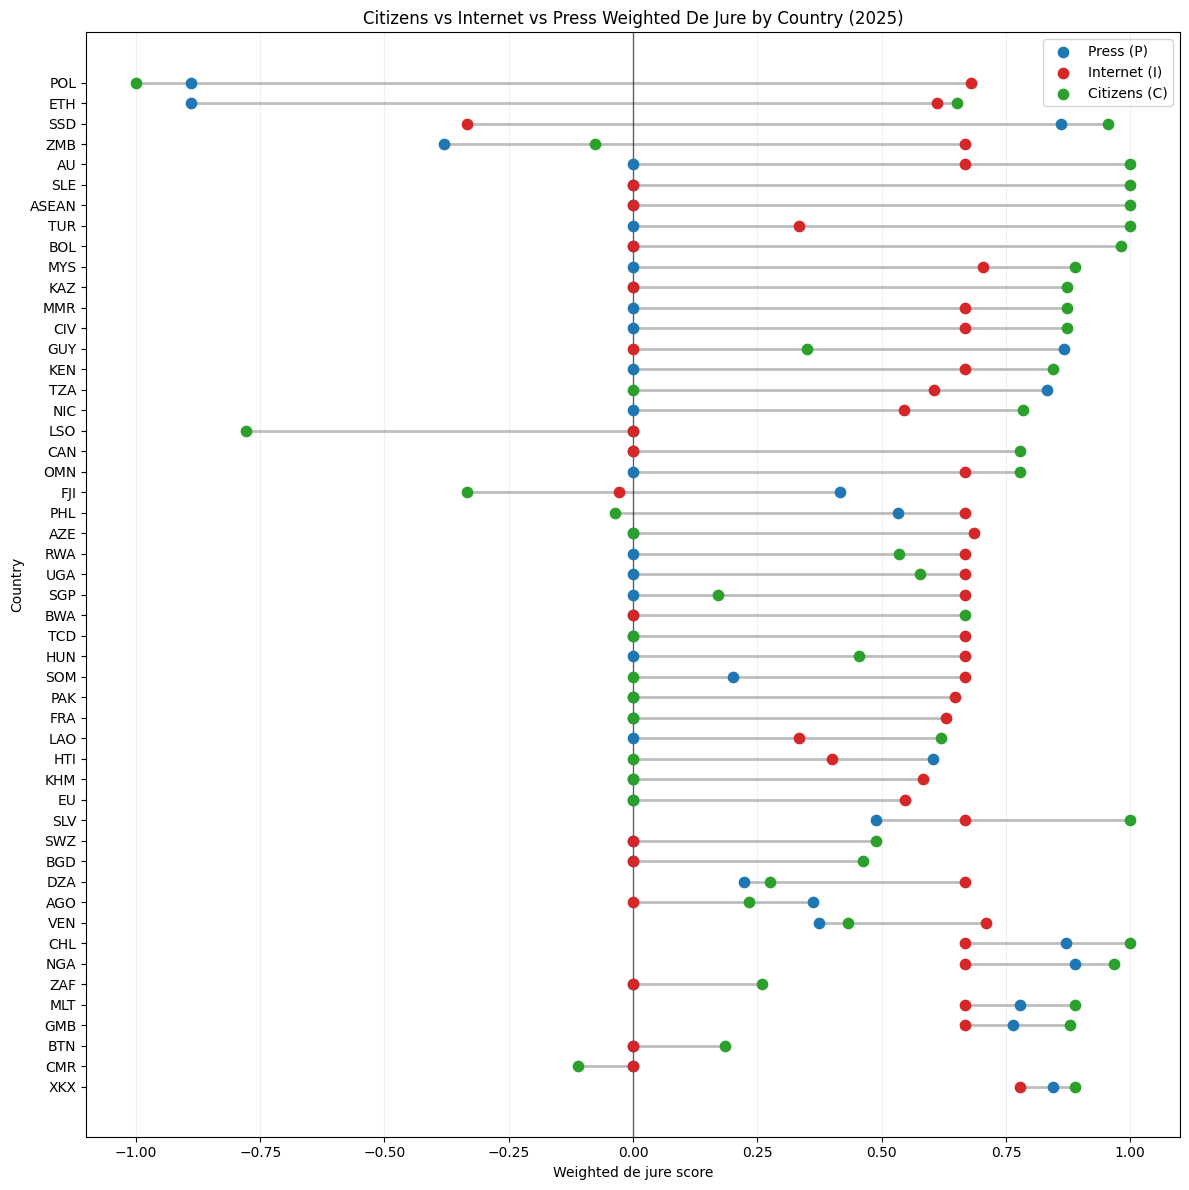

,COUNTRY,iso3,weighted_de_jure_P,weighted_de_jure_I,weighted_de_jure_C,spread,legal_rule_count_total
0,Kosovo,XKX,0.844444,0.777778,0.888889,0.111111,11
1,Cameroon,CMR,0.000000,0.000000,-0.111111,0.111111,9
2,Bhutan,BTN,0.000000,0.000000,0.185185,0.185185,9
3,The Gambia,GMB,0.763889,0.666667,0.878788,0.212121,21
4,Malta,MLT,0.777778,0.666667,0.888889,0.222222,9
5,South Africa,ZAF,0.000000,0.000000,0.259259,0.259259,4
6,Nigeria,NGA,0.888889,0.666667,0.968254,0.301587,18
7,Chile,CHL,0.870370,0.666667,1.000000,0.333333,14
8,Venezuela,VEN,0.374074,0.709402,0.432749,0.335328,56
9,Angola,AGO,0.361111,0.000000,0.232323,0.361111,19


In [24]:
plot_year = 2025

cip_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_C",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

cip_df = cip_df[
    (cip_df["weighted_de_jure_C"] != 0) |
    (cip_df["weighted_de_jure_I"] != 0) |
    (cip_df["weighted_de_jure_P"] != 0)
].copy()

cip_df["spread"] = (
    cip_df[["weighted_de_jure_C", "weighted_de_jure_I", "weighted_de_jure_P"]].max(axis=1)
    - cip_df[["weighted_de_jure_C", "weighted_de_jure_I", "weighted_de_jure_P"]].min(axis=1)
)

cip_df = cip_df.sort_values("spread").reset_index(drop=True)
y_pos = np.arange(len(cip_df))

plt.figure(figsize=(12, 12))

for i, row in cip_df.iterrows():
    x_values = sorted([
        row["weighted_de_jure_P"],
        row["weighted_de_jure_I"],
        row["weighted_de_jure_C"]
    ])
    plt.plot(
        [x_values[0], x_values[-1]],
        [y_pos[i], y_pos[i]],
        color="#bdbdbd",
        linewidth=2,
        zorder=1
    )

plt.scatter(
    cip_df["weighted_de_jure_P"],
    y_pos,
    color="#1f77b4",
    s=55,
    label="Press (P)",
    zorder=3
)

plt.scatter(
    cip_df["weighted_de_jure_I"],
    y_pos,
    color="#d62728",
    s=55,
    label="Internet (I)",
    zorder=3
)

plt.scatter(
    cip_df["weighted_de_jure_C"],
    y_pos,
    color="#2ca02c",
    s=55,
    label="Citizens (C)",
    zorder=3
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, cip_df["iso3"])
plt.xlabel("Weighted de jure score")
plt.ylabel("Country")
plt.title(f"Citizens vs Internet vs Press Weighted De Jure by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

cip_df[["COUNTRY", "iso3", "weighted_de_jure_P", "weighted_de_jure_I", "weighted_de_jure_C", "spread", "legal_rule_count_total"]]


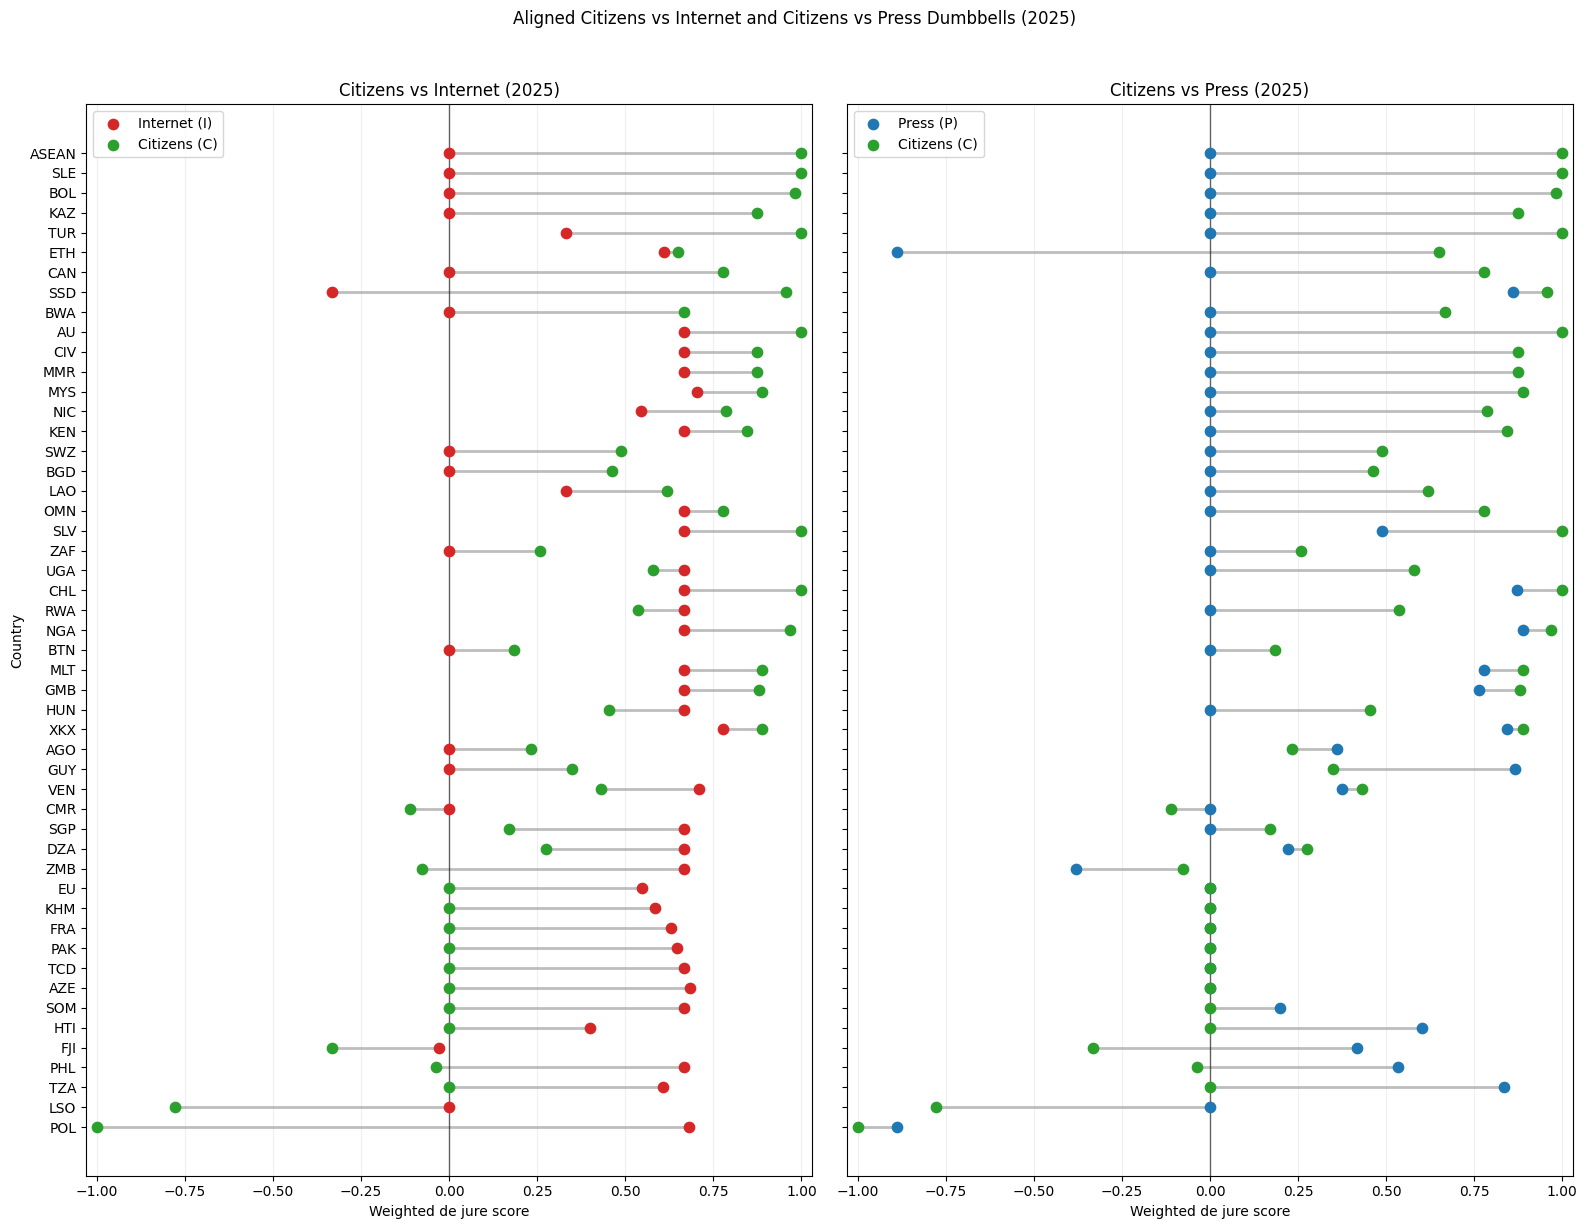

,COUNTRY,iso3,weighted_de_jure_P,weighted_de_jure_I,weighted_de_jure_C,gap_c_i,gap_c_p,legal_rule_count_total
0,Poland,POL,-0.888889,0.680556,-1.000000,-1.680556,-0.111111,19
1,Lesotho,LSO,0.000000,0.000000,-0.777778,-0.777778,-0.777778,1
2,Tanzania,TZA,0.833333,0.606061,0.000000,-0.606061,-0.833333,14
3,Philippines,PHL,0.533333,0.666667,-0.037037,-0.703704,-0.570370,17
4,Fiji,FJI,0.416667,-0.027778,-0.333333,-0.305556,-0.750000,19
5,Haiti,HTI,0.603175,0.400000,0.000000,-0.400000,-0.603175,26
6,Somalia,SOM,0.200000,0.666667,0.000000,-0.666667,-0.200000,8
7,Azerbaijan,AZE,0.000000,0.685185,0.000000,-0.685185,0.000000,9
8,Chad,TCD,0.000000,0.666667,0.000000,-0.666667,0.000000,5
9,Pakistan,PAK,0.000000,0.648148,0.000000,-0.648148,0.000000,8


In [25]:
plot_year = 2025

aligned_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_C",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

aligned_df = aligned_df[
    (aligned_df["weighted_de_jure_C"] != 0) |
    (aligned_df["weighted_de_jure_I"] != 0) |
    (aligned_df["weighted_de_jure_P"] != 0)
].copy()

aligned_df["gap_c_i"] = aligned_df["weighted_de_jure_C"] - aligned_df["weighted_de_jure_I"]
aligned_df["gap_c_p"] = aligned_df["weighted_de_jure_C"] - aligned_df["weighted_de_jure_P"]
aligned_df["sort_key"] = aligned_df[["gap_c_i", "gap_c_p"]].mean(axis=1)

aligned_df = aligned_df.sort_values("sort_key").reset_index(drop=True)
y_pos = np.arange(len(aligned_df))

x_min = aligned_df[["weighted_de_jure_C", "weighted_de_jure_I", "weighted_de_jure_P"]].min().min()
x_max = aligned_df[["weighted_de_jure_C", "weighted_de_jure_I", "weighted_de_jure_P"]].max().max()
pad = 0.03

fig, axes = plt.subplots(1, 2, figsize=(16, 12), sharey=True)

for i, row in aligned_df.iterrows():
    axes[0].plot(
        [row["weighted_de_jure_I"], row["weighted_de_jure_C"]],
        [y_pos[i], y_pos[i]],
        color="#bdbdbd",
        linewidth=2,
        zorder=1
    )
    axes[1].plot(
        [row["weighted_de_jure_P"], row["weighted_de_jure_C"]],
        [y_pos[i], y_pos[i]],
        color="#bdbdbd",
        linewidth=2,
        zorder=1
    )

axes[0].scatter(
    aligned_df["weighted_de_jure_I"],
    y_pos,
    color="#d62728",
    s=55,
    label="Internet (I)",
    zorder=3
)
axes[0].scatter(
    aligned_df["weighted_de_jure_C"],
    y_pos,
    color="#2ca02c",
    s=55,
    label="Citizens (C)",
    zorder=3
)

axes[1].scatter(
    aligned_df["weighted_de_jure_P"],
    y_pos,
    color="#1f77b4",
    s=55,
    label="Press (P)",
    zorder=3
)
axes[1].scatter(
    aligned_df["weighted_de_jure_C"],
    y_pos,
    color="#2ca02c",
    s=55,
    label="Citizens (C)",
    zorder=3
)

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(aligned_df["iso3"])
axes[0].set_ylabel("Country")

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#1f77b4", markersize=8, label="Press (P)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#d62728", markersize=8, label="Internet (I)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#2ca02c", markersize=8, label="Citizens (C)")
]

for ax, title in zip(
    axes,
    [
        f"Citizens vs Internet ({plot_year})",
        f"Citizens vs Press ({plot_year})"
    ]
):
    ax.axvline(0, color="black", linewidth=1, alpha=0.6)
    ax.set_xlim(x_min - pad, x_max + pad)
    ax.set_xlabel("Weighted de jure score")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.2)
    ax.legend()

fig.suptitle("Aligned Citizens vs Internet and Citizens vs Press Dumbbells (2025)", y=1.02)
plt.tight_layout()
plt.show()

aligned_df[["COUNTRY", "iso3", "weighted_de_jure_P", "weighted_de_jure_I", "weighted_de_jure_C", "gap_c_i", "gap_c_p", "legal_rule_count_total"]]


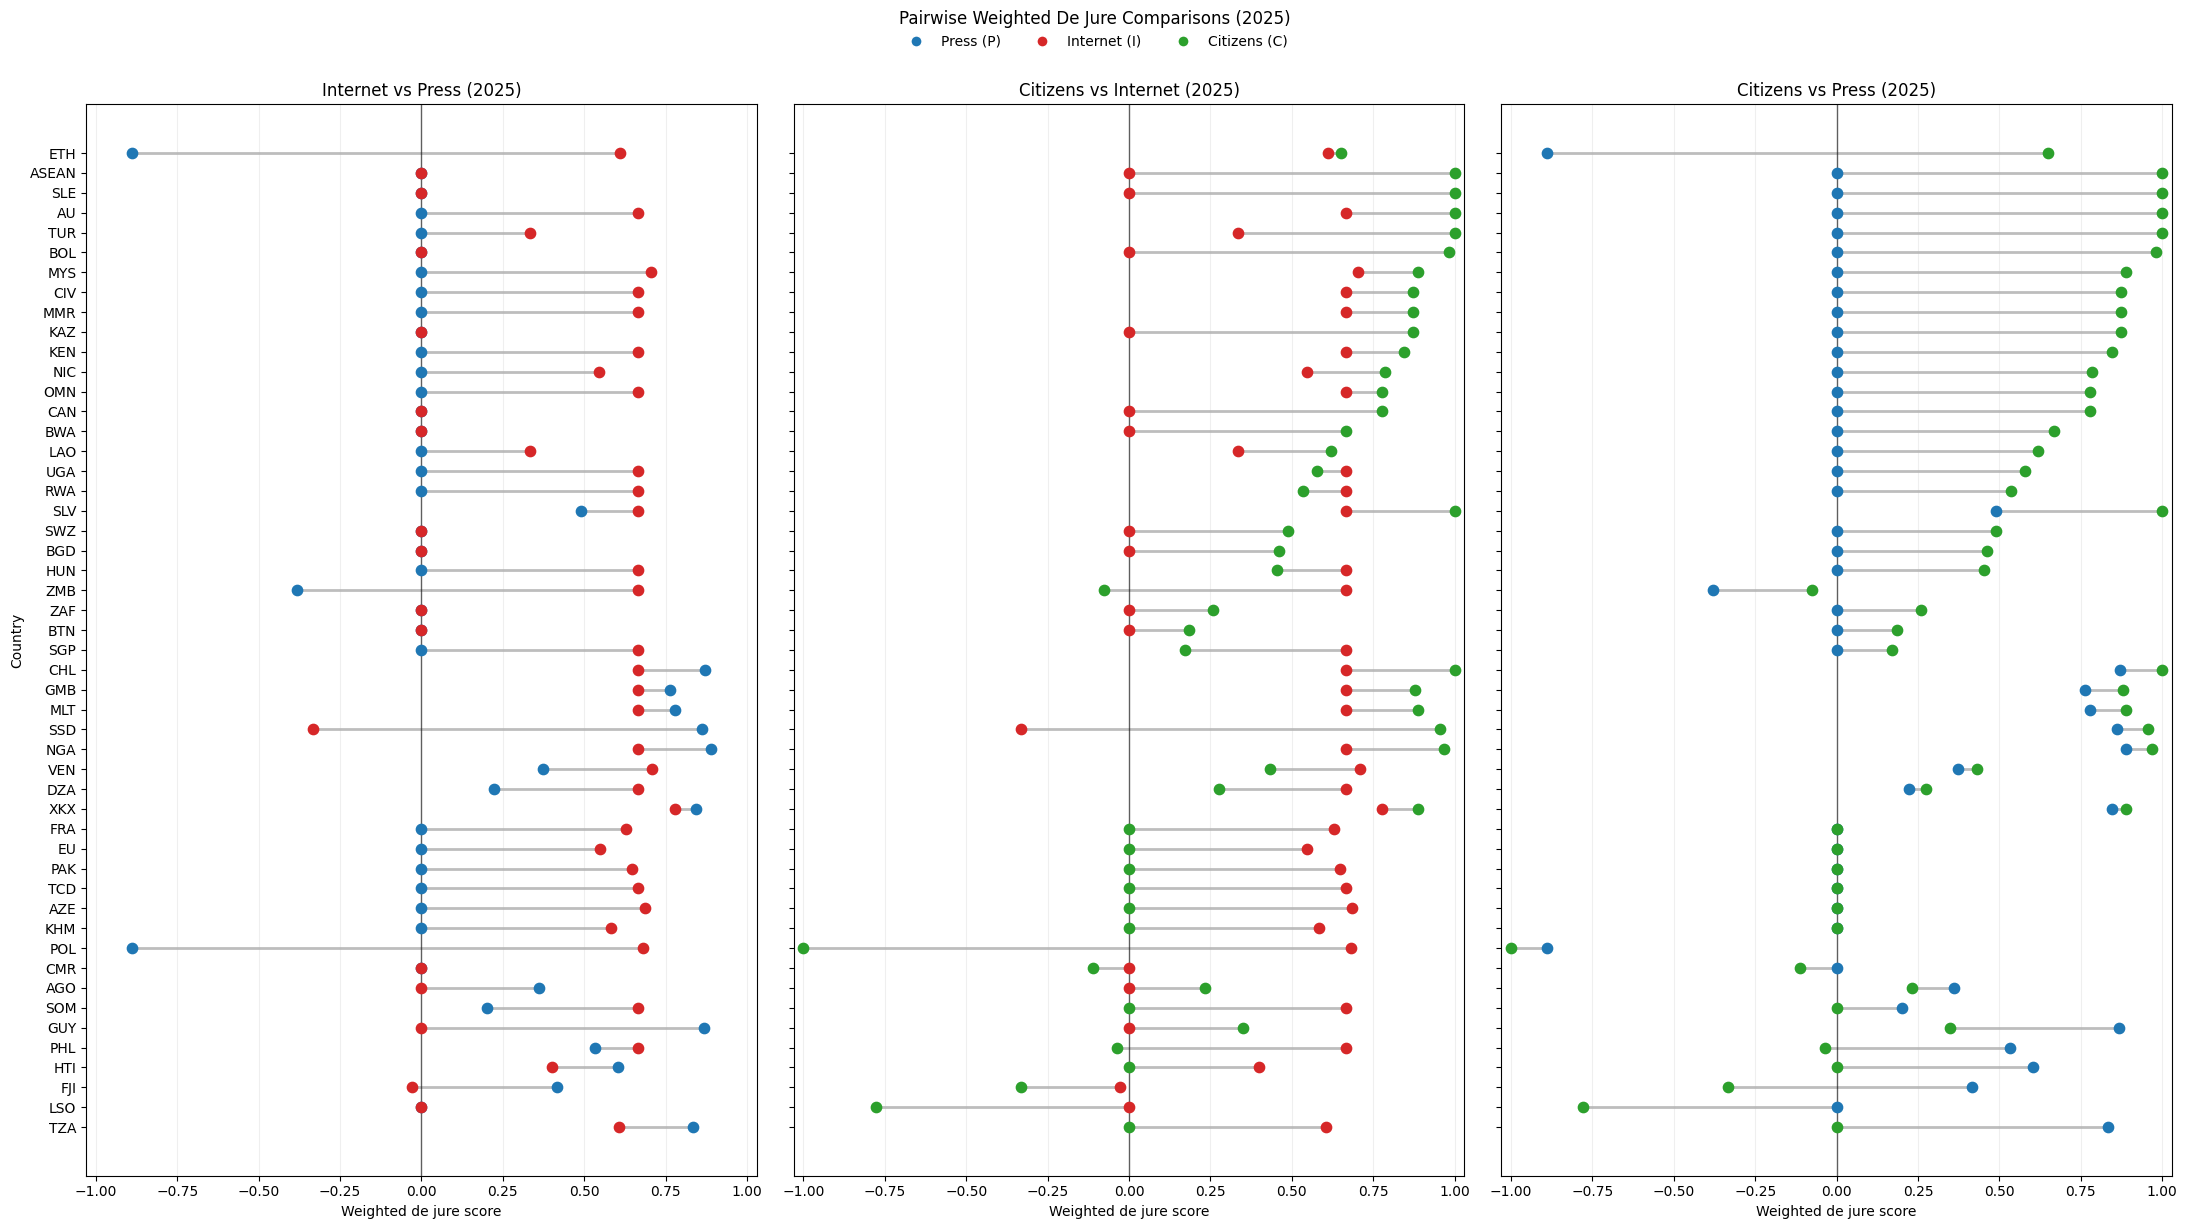

,COUNTRY,iso3,weighted_de_jure_P,weighted_de_jure_I,weighted_de_jure_C,gap_i_p,gap_c_i,gap_c_p,legal_rule_count_total
0,Tanzania,TZA,0.833333,0.606061,0.000000,-0.227273,-0.606061,-0.833333,14
1,Lesotho,LSO,0.000000,0.000000,-0.777778,0.000000,-0.777778,-0.777778,1
2,Fiji,FJI,0.416667,-0.027778,-0.333333,-0.444444,-0.305556,-0.750000,19
3,Haiti,HTI,0.603175,0.400000,0.000000,-0.203175,-0.400000,-0.603175,26
4,Philippines,PHL,0.533333,0.666667,-0.037037,0.133333,-0.703704,-0.570370,17
5,Guyana,GUY,0.866667,0.000000,0.349206,-0.866667,0.349206,-0.517460,15
6,Somalia,SOM,0.200000,0.666667,0.000000,0.466667,-0.666667,-0.200000,8
7,Angola,AGO,0.361111,0.000000,0.232323,-0.361111,0.232323,-0.128788,19
8,Cameroon,CMR,0.000000,0.000000,-0.111111,0.000000,-0.111111,-0.111111,9
9,Poland,POL,-0.888889,0.680556,-1.000000,1.569444,-1.680556,-0.111111,19


In [26]:
plot_year = 2025

from matplotlib.lines import Line2D

pairwise_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_C",
        "weighted_de_jure_I",
        "weighted_de_jure_P",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

pairwise_df = pairwise_df[
    (pairwise_df["weighted_de_jure_C"] != 0) |
    (pairwise_df["weighted_de_jure_I"] != 0) |
    (pairwise_df["weighted_de_jure_P"] != 0)
].copy()

pairwise_df["gap_i_p"] = pairwise_df["weighted_de_jure_I"] - pairwise_df["weighted_de_jure_P"]
pairwise_df["gap_c_i"] = pairwise_df["weighted_de_jure_C"] - pairwise_df["weighted_de_jure_I"]
pairwise_df["gap_c_p"] = pairwise_df["weighted_de_jure_C"] - pairwise_df["weighted_de_jure_P"]
pairwise_df["sort_key"] = pairwise_df[["gap_i_p", "gap_c_i", "gap_c_p"]].mean(axis=1)

pairwise_df = pairwise_df.sort_values("sort_key").reset_index(drop=True)
y_pos = np.arange(len(pairwise_df))

x_min = pairwise_df[["weighted_de_jure_C", "weighted_de_jure_I", "weighted_de_jure_P"]].min().min()
x_max = pairwise_df[["weighted_de_jure_C", "weighted_de_jure_I", "weighted_de_jure_P"]].max().max()
pad = 0.03

fig, axes = plt.subplots(1, 3, figsize=(22, 12), sharey=True)

for i, row in pairwise_df.iterrows():
    axes[0].plot(
        [row["weighted_de_jure_P"], row["weighted_de_jure_I"]],
        [y_pos[i], y_pos[i]],
        color="#bdbdbd",
        linewidth=2,
        zorder=1
    )
    axes[1].plot(
        [row["weighted_de_jure_I"], row["weighted_de_jure_C"]],
        [y_pos[i], y_pos[i]],
        color="#bdbdbd",
        linewidth=2,
        zorder=1
    )
    axes[2].plot(
        [row["weighted_de_jure_P"], row["weighted_de_jure_C"]],
        [y_pos[i], y_pos[i]],
        color="#bdbdbd",
        linewidth=2,
        zorder=1
    )

axes[0].scatter(
    pairwise_df["weighted_de_jure_P"],
    y_pos,
    color="#1f77b4",
    s=55,
    zorder=3
)
axes[0].scatter(
    pairwise_df["weighted_de_jure_I"],
    y_pos,
    color="#d62728",
    s=55,
    zorder=3
)

axes[1].scatter(
    pairwise_df["weighted_de_jure_I"],
    y_pos,
    color="#d62728",
    s=55,
    zorder=3
)
axes[1].scatter(
    pairwise_df["weighted_de_jure_C"],
    y_pos,
    color="#2ca02c",
    s=55,
    zorder=3
)

axes[2].scatter(
    pairwise_df["weighted_de_jure_P"],
    y_pos,
    color="#1f77b4",
    s=55,
    zorder=3
)
axes[2].scatter(
    pairwise_df["weighted_de_jure_C"],
    y_pos,
    color="#2ca02c",
    s=55,
    zorder=3
)

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(pairwise_df["iso3"])
axes[0].set_ylabel("Country")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#1f77b4", markersize=8, label="Press (P)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d62728", markersize=8, label="Internet (I)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2ca02c", markersize=8, label="Citizens (C)")
]

for ax, title in zip(
    axes,
    [
        f"Internet vs Press ({plot_year})",
        f"Citizens vs Internet ({plot_year})",
        f"Citizens vs Press ({plot_year})"
    ]
):
    ax.axvline(0, color="black", linewidth=1, alpha=0.6)
    ax.set_xlim(x_min - pad, x_max + pad)
    ax.set_xlabel("Weighted de jure score")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.2)

fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("Pairwise Weighted De Jure Comparisons (2025)", y=1.02)
plt.tight_layout()
plt.show()

pairwise_df[["COUNTRY", "iso3", "weighted_de_jure_P", "weighted_de_jure_I", "weighted_de_jure_C", "gap_i_p", "gap_c_i", "gap_c_p", "legal_rule_count_total"]]
